In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('housing.csv')

In [3]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [5]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [6]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [7]:
df.corr(numeric_only = True)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924664,-0.108197,0.044568,0.069608,0.099773,0.055310,-0.015176,-0.045967
latitude,-0.924664,1.000000,0.011173,-0.036100,-0.066983,-0.108785,-0.071035,-0.079809,-0.144160
housing_median_age,-0.108197,0.011173,1.000000,-0.361262,-0.320451,-0.296244,-0.302916,-0.119034,0.105623
total_rooms,0.044568,-0.036100,-0.361262,1.000000,0.930380,0.857126,0.918484,0.198050,0.134153
total_bedrooms,0.069608,-0.066983,-0.320451,0.930380,1.000000,0.877747,0.979728,-0.007723,0.049686
population,0.099773,-0.108785,-0.296244,0.857126,0.877747,1.000000,0.907222,0.004834,-0.024650
households,0.055310,-0.071035,-0.302916,0.918484,0.979728,0.907222,1.000000,0.013033,0.065843
median_income,-0.015176,-0.079809,-0.119034,0.198050,-0.007723,0.004834,0.013033,1.000000,0.688075
median_house_value,-0.045967,-0.144160,0.105623,0.134153,0.049686,-0.024650,0.065843,0.688075,1.000000


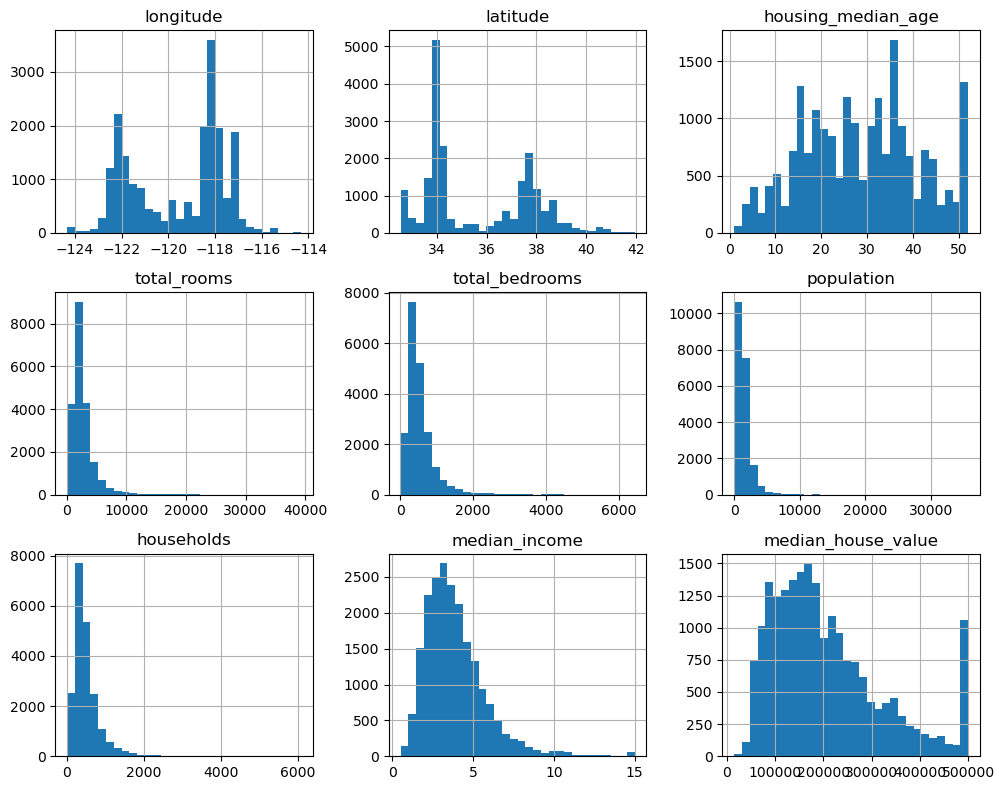

In [8]:
df.hist(bins = 30,grid = True,figsize = (10,8))
plt.tight_layout()

In [9]:
df['income_cat'] = pd.cut(df['median_income'],bins = [0.0,1.5,3.0,4.5,6.0,np.inf],labels = [1,2,3,4,5])

In [10]:
# df['median_income'].value_counts().sort_index().plot.bar(grid = True,rot = 1)

In [11]:
from sklearn.model_selection import StratifiedShuffleSplit
split = StratifiedShuffleSplit(n_splits = 1, test_size = 0.2,random_state = 42)
for (train_set,test_set) in split.split(df,df['income_cat']):
    strat_train_set = df.loc[train_set]
    strat_test_set = df.loc[test_set]

<Axes: xlabel='income_cat'>

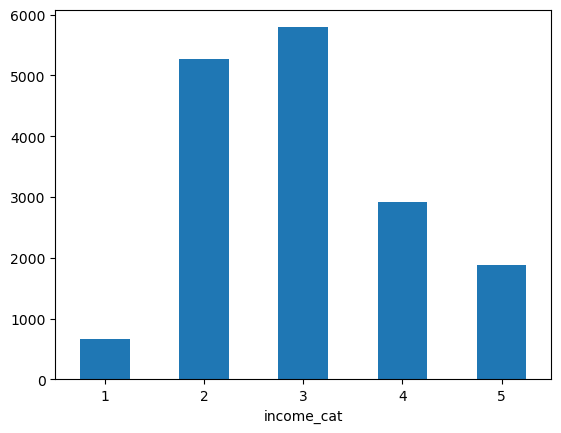

In [12]:
strat_train_set['income_cat'].value_counts().sort_index().plot.bar(rot = 1)

<Axes: xlabel='income_cat'>

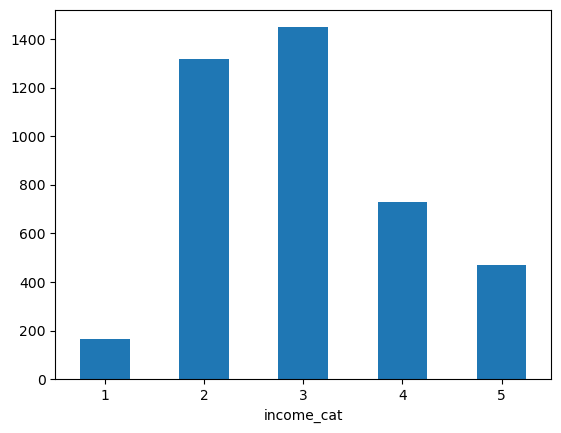

In [13]:
strat_test_set['income_cat'].value_counts().sort_index().plot.bar(rot = 1)

In [14]:
for sett in (strat_train_set,strat_test_set):
    sett.drop('income_cat', axis = 1  ,inplace = True)

In [15]:
df = strat_train_set.copy()

In [16]:
print(type(df))

<class 'pandas.core.frame.DataFrame'>


<Axes: xlabel='latitude', ylabel='longitude'>

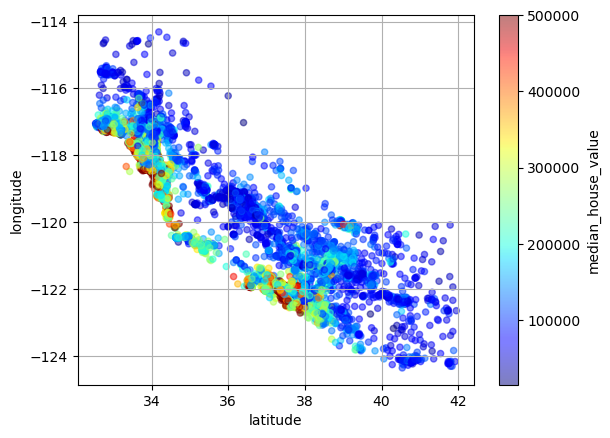

In [17]:
df.plot(kind = 'scatter', x='latitude', y='longitude',grid = True , alpha = 0.5, cmap = 'jet', c= 'median_house_value')

In [18]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
12655,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736,72100.0,INLAND
15502,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373,279600.0,NEAR OCEAN
2908,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.8750,82700.0,INLAND
14053,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264,112500.0,NEAR OCEAN
20496,-118.70,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964,238300.0,<1H OCEAN


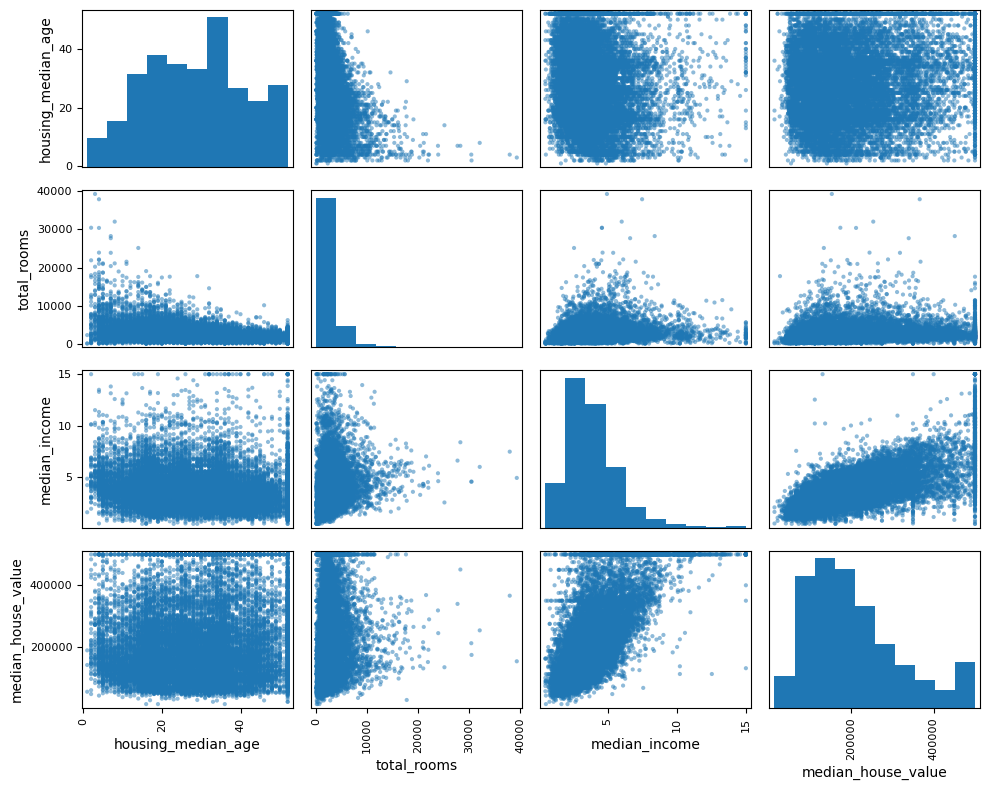

In [19]:
from pandas.plotting import scatter_matrix
attributes = ['housing_median_age', 'total_rooms', 'median_income', 'median_house_value']
scatter_matrix(df[attributes],figsize = (10,8) )
plt.tight_layout()
plt.show()

In [20]:
housing = df.drop('median_house_value',axis = 1)
housing_labels = df['median_house_value']

In [21]:
x_test = strat_test_set.drop('median_house_value', axis = 1)
y_labels = strat_test_set['median_house_value']

In [22]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy = 'median')
housing_num = housing.select_dtypes(include = [np.number])
x = imputer.fit_transform(housing_num)

In [23]:
x_test_num = x_test.select_dtypes(include = [np.number])
x_test_impute = imputer.transform(x_test_num)

In [24]:
df = pd.DataFrame(x , columns = housing_num.columns, index = housing_num.index)

In [25]:
df["ocean_proximity"] = housing["ocean_proximity"]
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
12655,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736,INLAND
15502,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373,NEAR OCEAN
2908,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.8750,INLAND
14053,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264,NEAR OCEAN
20496,-118.70,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964,<1H OCEAN
...,...,...,...,...,...,...,...,...,...
15174,-117.07,33.03,14.0,6665.0,1231.0,2026.0,1001.0,5.0900,<1H OCEAN
12661,-121.42,38.51,15.0,7901.0,1422.0,4769.0,1418.0,2.8139,INLAND
19263,-122.72,38.44,48.0,707.0,166.0,458.0,172.0,3.1797,<1H OCEAN
19140,-122.70,38.31,14.0,3155.0,580.0,1208.0,501.0,4.1964,<1H OCEAN


In [26]:
df.isnull().sum().sum()

0

In [27]:
df2 = pd.DataFrame(x_test_impute, columns = x_test_num.columns, index = x_test_num.index)

In [28]:
df2["ocean_proximity"] = x_test["ocean_proximity"]

In [29]:
df2.isnull().sum().sum()

0

In [30]:
housing_cat = df[['ocean_proximity']]

In [31]:
x_test_cat = df2[['ocean_proximity']]

In [32]:
from sklearn.preprocessing import OneHotEncoder
oh_encoding = OneHotEncoder()
housing_encode = oh_encoding.fit_transform(housing_cat)

In [33]:
housing_encode.toarray()

array([[0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 0.],
       ...,
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.]])

In [34]:
x_test_encode = oh_encoding.transform(x_test_cat)
encoded_xtest_cat = pd.DataFrame(x_test_encode.toarray(), columns = ['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'], index = x_test.index)

In [35]:
x_test_drop = df2.drop('ocean_proximity', axis = 1)

In [36]:
encoded_cat = pd.DataFrame(housing_encode.toarray(), columns = ['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'], index = housing.index)

In [37]:
encoded_cat.head()

,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
12655,0.0,1.0,0.0,0.0,0.0
15502,0.0,0.0,0.0,0.0,1.0
2908,0.0,1.0,0.0,0.0,0.0
14053,0.0,0.0,0.0,0.0,1.0
20496,1.0,0.0,0.0,0.0,0.0


In [38]:
df_train = df.drop('ocean_proximity', axis = 1)

In [39]:
from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler()
scaled = scaler.fit_transform(df_train)

In [40]:
scaled_test = scaler.transform(x_test_drop)

In [41]:
scaled_test_set = pd.DataFrame(scaled_test, columns = x_test_drop.columns, index = x_test_drop.index)

In [42]:
df_test_t = pd.concat([scaled_test_set,encoded_xtest_cat],axis = 1)

In [43]:
scaled_data = pd.DataFrame(scaled, columns = df_train.columns, index = df_train.index)

In [44]:
df_t = pd.concat([scaled_data,encoded_cat],axis = 1)

In [45]:
scaled_data.index.equals(encoded_cat.index)

True

In [46]:
X_train = df_t
y_train = housing_labels

In [47]:
X_test = df_test_t
y_test = y_labels

In [48]:
# X_test.isnull().sum()

In [49]:
# X_train.isnull().sum()

In [50]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [51]:
y_pred = model.predict(X_test)

In [52]:
y_pred

array([419992.00048286, 291826.87053631, 245738.10411714, ...,
       310328.92625752, 268246.11802886, 241115.24025364])

In [53]:
comparision_table = pd.DataFrame({ 'actual_values ': y_test.values,
"predicted_values": y_pred})

In [54]:
comparision_table.head(10)

,actual_values,predicted_values
0,500001.0,419992.000483
1,162500.0,291826.870536
2,204600.0,245738.104117
3,159700.0,195557.301127
4,184000.0,264439.451603
5,151900.0,219939.264450
6,104900.0,162387.600078
7,500001.0,366109.128243
8,367400.0,289174.890394
9,346500.0,231143.751817


The table compares actual house prices with predicted values on the test set.
The absolute error column highlights the deviation of predictions from true values, helping to understand model accuracy at an individual sample lev

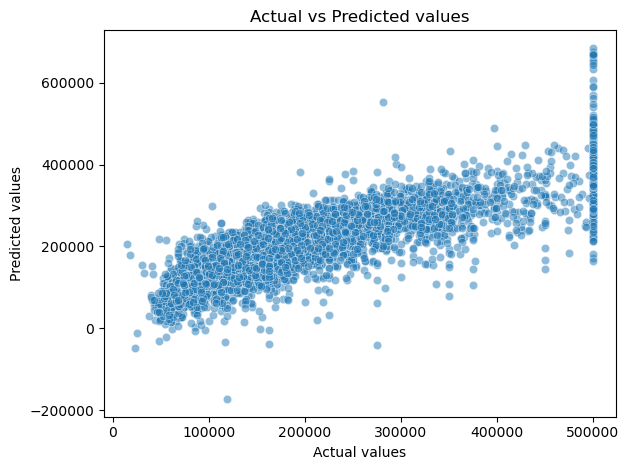

In [55]:
sns.scatterplot(x = y_test.values, y = y_pred, alpha = 0.5)
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.title("Actual vs Predicted values")
plt.tight_layout()

The model captures the overall linear trend reasonably well, but shows higher variance for expensive houses, struggles due to target value capping at 500,000, and produces some unrealistic negative predictions, indicating scope for improvement with non-linear models

In [56]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [57]:
mae = mean_absolute_error(y_test,y_pred)
rmse = mean_squared_error(y_test,y_pred)

In [58]:
mae

49775.59569942189

In [59]:
rmse

4535602240.029962

The model was evaluated using MAE and RMSE, which are appropriate regression metrics.
MAE measures average prediction error, while RMSE penalizes larger errors more heavily.

In [60]:
coefficient = pd.Series(model.coef_,index = X_train.columns).sort_values(ascending = False)
coefficient

ISLAND                112925.817971
median_income          73737.442494
total_bedrooms         29937.919033
households             28900.335622
housing_median_age     13723.557529
total_rooms           -10022.164197
NEAR OCEAN            -14432.754419
<1H OCEAN             -18139.052945
NEAR BAY              -22517.510789
population            -43815.820091
longitude             -53158.467529
latitude              -54016.744209
INLAND                -57836.499819
dtype: float64

The linear regression coefficients indicate that median income and location-related features have the strongest influence on house prices. Island proximity significantly increases predicted prices, while inland locations and high population density are associated with lower house values. Some size-related variables show mixed effects due to multicollinearity.

In [61]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor()
model.fit(X_train,y_train)

RandomForestRegressor()

In [62]:
y_pred =  model.predict(X_test)

In [63]:
mae = mean_absolute_error(y_pred,y_test)
mae

31060.422860949613

In [64]:
rmse = mean_squared_error(y_pred,y_test)
rmse

2221073363.3613057

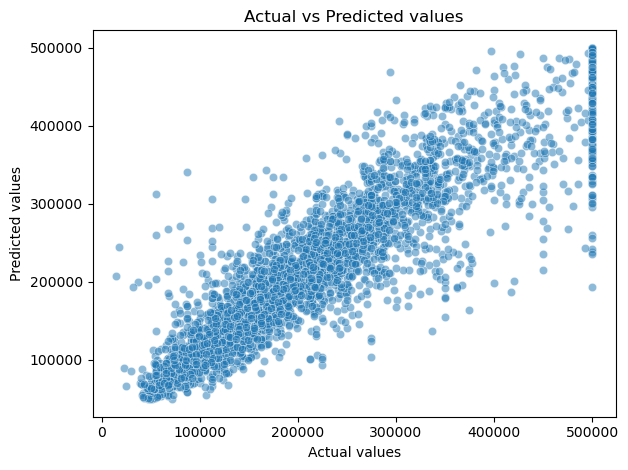

In [65]:
sns.scatterplot(x = y_test.values, y = y_pred, alpha = 0.5)
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.title("Actual vs Predicted values")
plt.tight_layout()

“Random Forest significantly improved prediction accuracy over Linear Regression by reducing error variance and better fitting non-linear patterns in the housing data.”

In [68]:
feature_importance = pd.Series(model.feature_importances_,index = X_train.columns).sort_values(ascending = False)
feature_importance.head(10)

median_income         0.482305
INLAND                0.143745
longitude             0.108196
latitude              0.104170
housing_median_age    0.051203
population            0.031696
total_rooms           0.025491
total_bedrooms        0.021400
households            0.021397
NEAR OCEAN            0.005918
dtype: float64

“The Random Forest model identifies median income as the most influential feature, followed by geographic location variables, while property size and ocean proximity categories contribute relatively less to prediction accuracy.”

# linear regression vs random forest regressor

Linear Regression assumes linear relationships and is sensitive to multicollinearity, whereas Random Forest captures non-linear interactions and complex feature dependencies, resulting in improved predictive performance.

##  Model Evaluation Metrics

To evaluate the regression model performance, Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) were used.

###  Mean Absolute Error (MAE)
MAE measures the average absolute difference between actual and predicted house prices.
It provides a clear interpretation of how much the model’s predictions deviate on average.

###  Root Mean Squared Error (RMSE)
RMSE penalizes larger errors more than MAE by squaring the residuals.
It helps identify whether the model makes large prediction mistakes.

###  Interpretation
- MAE < RMSE, which is expected since RMSE penalizes large errors.
- The values indicate that the model predicts house prices with reasonable accuracy.
- The model does not suffer from frequent extreme prediction errors.

Overall, the model demonstrates good predictive performance for housing price estimation.
